
## AdaBoost 


1. **Visualization:** How **AdaBoost** increases emphasis (weights) on hard samples across iterations.
2. **Explanation:** A concise, trainer-friendly walkthrough of the AdaBoost algorithm.
3. **Comparison Table:** AdaBoost vs **Gradient Boosting** on a simple synthetic dataset.




## 1) AdaBoost — Concept Recap (Trainer Notes)

**Idea:** Build many weak learners sequentially (typically **decision stumps** = depth‑1 trees). Each step **upweights** misclassified samples so the next learner focuses on what previous ones got wrong. Final prediction is a **weighted vote** of all weak learners.

**Key quantities per iteration _t_:**
- Weighted error: $arepsilon_t = \sum_i w_i^{(t)} \cdot [h_t(x_i) 
eq y_i]$
- Learner weight: $lpha_t = 	frac{1}{2}\ln 	frac{1-arepsilon_t}{arepsilon_t}$
- Sample weights: $w_i^{(t+1)} \propto w_i^{(t)} \cdot e^{lpha_t \cdot [h_t(x_i) 
eq y_i]}$ (renormalized)

**Practical defaults:**
- `estimator=DecisionTreeClassifier(max_depth=1)` (stump)
- `n_estimators=50` to `200` for quick demos
- `learning_rate` in `[0.1, 1.0]` to scale each learner’s contribution



## 2) Setup & Data


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
import time

sns.set(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Generate a 2D, non-trivial but quick dataset
X, y = make_classification(
    n_samples=600, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.1, random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

##  startify: ensure balanced representation of classess

((450, 2), (150, 2))


## 3) Train AdaBoost (Decision Stumps) & Capture Iteration Stats
We’ll use scikit-learn’s **`estimator_errors_`** and **`estimator_weights_`** to visualize how emphasis evolves. We’ll also track the **distribution of sample weights** over iterations.


In [2]:

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=100,
    learning_rate=0.8,
    random_state=RANDOM_STATE
)
ada.fit(X_train, y_train)

errors = getattr(ada, 'estimator_errors_', None)
weights = getattr(ada, 'estimator_weights_', None)

print(f"Trained AdaBoost with {len(ada.estimators_)} estimators")
print("First 5 estimator errors:", np.round(errors[:5], 4))
print("First 5 estimator weights:", np.round(weights[:5], 4))


Trained AdaBoost with 100 estimators
First 5 estimator errors: [0.0822 0.2824 0.142  0.2497 0.2125]
First 5 estimator weights: [1. 1. 1. 1. 1.]



### 3a) Visualize Estimator Errors & Weights per Iteration
- **Estimator error** should generally be < 0.5 for a learner to get a positive weight.
- **Estimator weight** (alpha) grows as error drops.


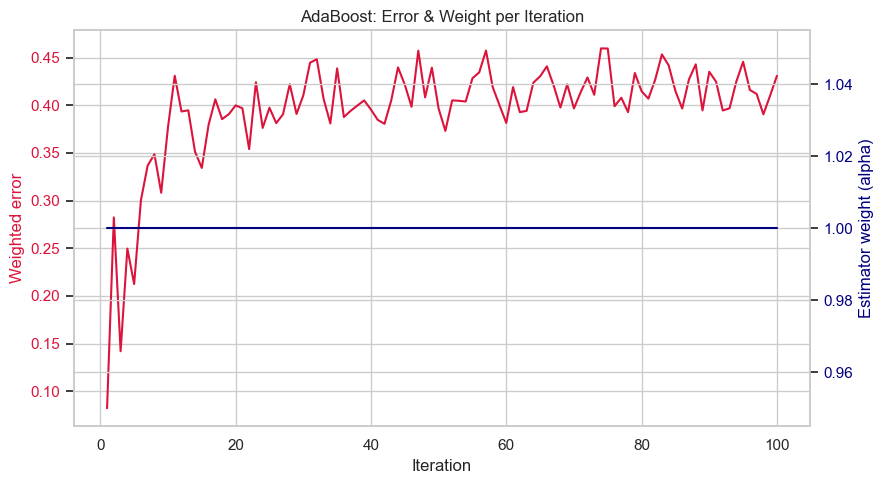

In [3]:

fig, ax1 = plt.subplots(figsize=(9, 5))
its = np.arange(1, len(errors)+1)
ax1.plot(its, errors, color='crimson', label='Estimator error')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Weighted error', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')

ax2 = ax1.twinx()
ax2.plot(its, weights, color='navy', label='Estimator weight (alpha)')
ax2.set_ylabel('Estimator weight (alpha)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

plt.title('AdaBoost: Error & Weight per Iteration')
fig.tight_layout()
plt.show()



### 3b) Visualize Sample Weight Distribution Over Iterations
We’ll reconstruct how **sample weights spread** as training proceeds. (For speed, we snapshot every 5 iterations.)


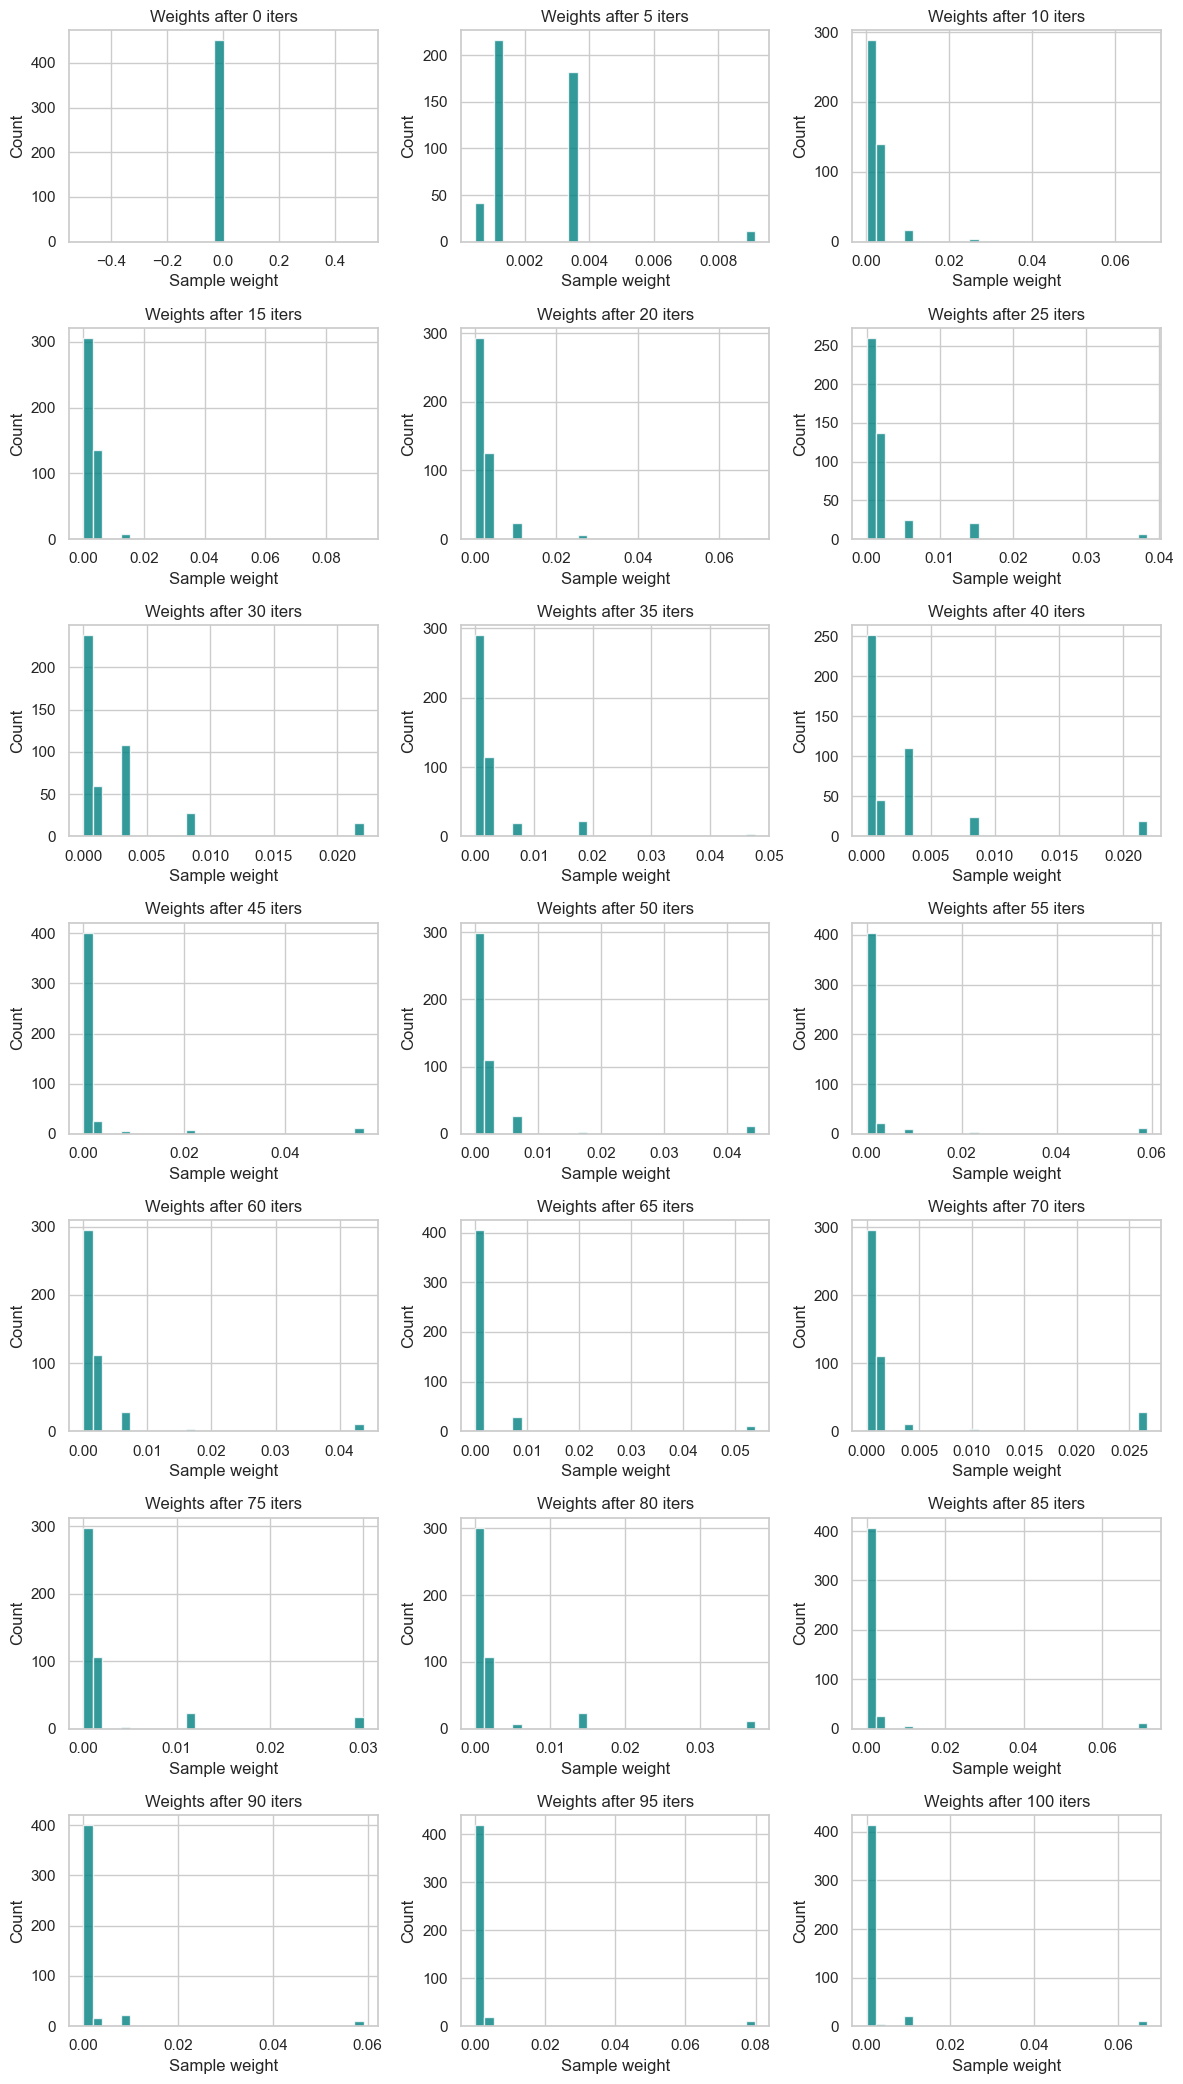

In [4]:

# Reconstruct per-iteration sample weights using the AdaBoost update rule
# Start with uniform weights
n = X_train.shape[0]
w = np.ones(n) / n

snapshots = {0: w.copy()}

from sklearn.base import clone

# Walk through estimators and update weights as AdaBoost would
for t, est in enumerate(ada.estimators_):
    # Note: scikit-learn stores errors & weights for each estimator already
    err_t = errors[t]
    alpha_t = weights[t]

    # Predict on training set for this estimator
    y_pred_t = est.predict(X_train)
    misclassified = (y_pred_t != y_train)

    # Update weights: multiply by exp(alpha) where misclassified
    w *= np.exp(alpha_t * misclassified)
    w /= w.sum()  # normalize

    if (t+1) % 5 == 0:
        snapshots[t+1] = w.copy()

# Plot histograms of weight distributions at snapshots
cols = 3
rows = int(np.ceil(len(snapshots)/cols))
plt.figure(figsize=(cols*4, rows*3))
for i, (t, w_snap) in enumerate(sorted(snapshots.items())):
    ax = plt.subplot(rows, cols, i+1)
    ax.hist(w_snap, bins=30, color='teal', alpha=0.8)
    ax.set_title(f'Weights after {t} iters')
    ax.set_xlabel('Sample weight')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()



## 4) Decision Boundary (Optional Visual)


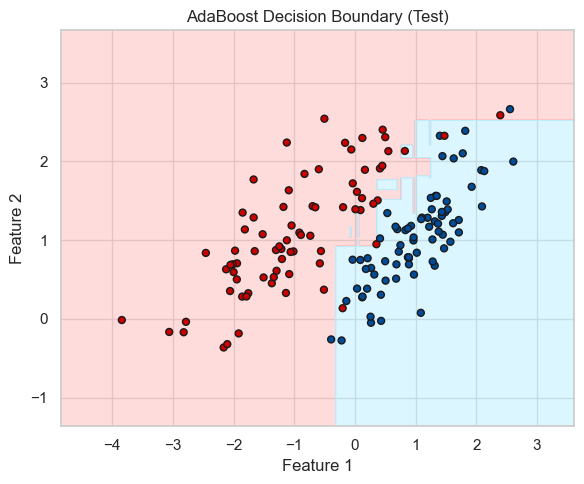

In [5]:

# Quick decision boundary on test set
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X, y, title='Decision Boundary'):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_light = ListedColormap(['#FFBBBB', '#BBEEFF'])
    cmap_bold = ListedColormap(['#CC0000', '#004C99'])

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap_bold, edgecolors='k', s=25)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.tight_layout()
    plt.show()

plot_decision_boundary(ada, X_test, y_test, title='AdaBoost Decision Boundary (Test)')



## 5) AdaBoost vs Gradient Boosting — Comparison Table
We’ll compare **Accuracy**, **F1**, **ROC‑AUC**, and **Fit Time (s)**. Both are trained with quick, reasonable defaults.


In [ ]:

# Train Gradient Boosting
start = time.time()
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
gb_time = time.time() - start

# Evaluate both models
models = {
    'AdaBoost (stumps)': ada,
    'GradientBoosting': gb
}

records = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    try:
        proba = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, proba)
    except Exception:
        auc = np.nan
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fit_time = np.nan if 'AdaBoost' not in name else np.nan  # captured below
    records.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC_AUC': auc, 'Fit_Time_s': fit_time})

# Capture AdaBoost fit time retrospectively by re-fitting quickly (warm start off)
start = time.time()
_ = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=100,
    learning_rate=0.8,
    random_state=RANDOM_STATE
).fit(X_train, y_train)
ada_time = time.time() - start

for r in records:
    if r['Model'].startswith('AdaBoost'):
        r['Fit_Time_s'] = ada_time
    else:
        r['Fit_Time_s'] = gb_time

comp_df = pd.DataFrame(records)
comp_df = comp_df[['Model','Accuracy','F1','ROC_AUC','Fit_Time_s']]

# Nicely formatted table
comp_df_style = comp_df.copy()
comp_df_style.style.format({'Accuracy': '{:.4f}', 'F1': '{:.4f}', 'ROC_AUC': '{:.4f}', 'Fit_Time_s': '{:.3f}'})



### 5a) Visual Comparison (Accuracy)


In [ ]:

plt.figure(figsize=(6,4))
sns.barplot(data=comp_df, x='Accuracy', y='Model', palette='viridis')
plt.xlim(0,1)
plt.title('AdaBoost vs Gradient Boosting — Accuracy')
plt.tight_layout()
plt.show()

comp_df



## 6) Takeaways
- **AdaBoost** increases the influence of hard samples via **growing sample weights**; learners with lower error get **higher alpha weights**.
- **Gradient Boosting** reduces loss by **fitting residuals** stage‑wise; no explicit sample reweighting is surfaced, but additive trees minimize a differentiable loss.
- On simple tabular data, both perform competitively; runtime and stability can vary with hyperparameters and data complexity.
